# 双均线（Dual MA）策略回测 · Task 3

基于 `Task 3/data/raw/` 下 4 只 A 股的**后复权**日线数据，构建双均线趋势跟踪策略并回测。

**方法要点**
- **策略**：快线 `MA_short`（默认 5 日）+ 慢线 `MA_long`（默认 20 日）。
- **信号**：交叉事件驱动 —— `cross_t − cross_{t-1} = +2` 金叉买入、`= −2` 死叉卖出；初始空仓，避免"凭空满仓"。
- **前视偏差规避**：第 t 日持仓由截至 t-1 日的交叉事件决定，t 日才成交。
- **交易成本**：单边万三（0.0003），仅在持仓切换（买/卖）当日扣除；买入持有基准同样在建仓时扣除单边成本。
- **评价指标**：累计回报、年化收益、最大回撤 MDD（取绝对值）、夏普（年化 ×√252）、索提诺、卡玛，并与买入持有对照。
- **回测区间**：起止日期可调（`start_date` / `end_date`），便于做区间敏感性分析。

> 完整规范见 `dual_ma_backtest_spec.md`；可交互调参看板见 `dual_ma_dashboard.html`。


In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 将当前目录加入路径，import 回测引擎
sys.path.insert(0, os.path.abspath(''))
from dual_ma_backtest import (DEFAULTS, NAME_MAP, load_stock, compute_signals,
                              backtest, compute_metrics, run_one, run_all)

print("默认参数:", DEFAULTS)


默认参数: {'N_short': 5, 'N_long': 20, 'rf_annual': 0.0, 'annualization': 252, 'initial_capital': 1.0, 'commission': 0.0003, 'start_date': None, 'end_date': None}


## 1. 数据（后复权）

`close` 为真正连续的后复权价（已抹平除权除息跳空，如比亚迪 2025-07-29 拆股 -66.9% 断点）。
读取务必用 `utf-8-sig` 去 BOM。

In [2]:
raw_dir = os.path.join(os.path.abspath(''), 'data', 'raw')
files = sorted([f for f in os.listdir(raw_dir) if f.endswith('.csv')])
print("数据文件:", files)

# 回测区间（可调）：'YYYY-MM-DD' 或 None 表示全区间
START_DATE = None
END_DATE   = None

# 载入示范股：三一重工
demo_code = '600031.SH'
demo_df = load_stock(os.path.join(raw_dir, f"{demo_code}_20250703_20260703.csv"), START_DATE, END_DATE)
print(f"\n{demo_code} {NAME_MAP[demo_code]}  行数={len(demo_df)}  区间={demo_df.index[0].date()} ~ {demo_df.index[-1].date()}")
demo_df[['close', 'open', 'high', 'low']].head(3)


数据文件: ['002594.SZ_20250703_20260703.csv', '600031.SH_20250703_20260703.csv', '600900.SH_20250703_20260703.csv', '688981.SH_20250703_20260703.csv']

600031.SH 三一重工  行数=243  区间=2025-07-02 ~ 2026-07-02


,close,open,high,low
trade_date,,,,
2025-07-02,18.20,17.80,18.39,17.73
2025-07-03,18.16,18.20,18.21,18.07
2025-07-04,18.23,18.16,18.30,18.05


## 2. 双均线与交叉事件信号

`cross_t = +1`（`MA_short > MA_long`）/ `−1`（`MA_short < MA_long`）/ `0`（相等）/ `NaN`（均线未就绪）。
金叉 = `cross_{t-1} − cross_{t-2} = +2`，死叉 = `−2`。前 `N_long−1` 日均线无值，期间空仓。

In [3]:
N_short, N_long = DEFAULTS['N_short'], DEFAULTS['N_long']
sig = compute_signals(demo_df, N_short, N_long)

n_golden = int(sig['golden'].sum())
n_death  = int(sig['death'].sum())
print(f"MA{N_short}/{N_long} → 金叉次数={n_golden}, 死叉次数={n_death}, 总交易切换={int(sig['switch'].sum())}")
print("前 6 行均线 / 方向 / 信号：")
sig[['close','ma_short','ma_long','cross','golden','death','pos']].head(6)


MA5/20 → 金叉次数=8, 死叉次数=9, 总交易切换=16
前 6 行均线 / 方向 / 信号：


,close,ma_short,ma_long,cross,golden,death,pos
trade_date,,,,,,,
2025-07-02,18.20,NaN,NaN,NaN,False,False,0.0
2025-07-03,18.16,NaN,NaN,NaN,False,False,0.0
2025-07-04,18.23,NaN,NaN,NaN,False,False,0.0
2025-07-07,18.35,NaN,NaN,NaN,False,False,0.0
2025-07-08,19.07,18.402,NaN,NaN,False,False,0.0
2025-07-09,19.11,18.584,NaN,NaN,False,False,0.0


## 3. 回测（含万三成本）

策略日收益 `strat_r_t = pos_t · r_t − commission · switch_t`，净值 `equity_t = equity_{t-1}·(1+strat_r_t)`。
买入持有净值 `bh_t = ∏(1+r_t)` 作为对照基准。

In [4]:
comm = DEFAULTS['commission']
bt = backtest(sig, comm)
met = compute_metrics(bt, DEFAULTS['rf_annual'], DEFAULTS['annualization'])
met['N_short'], met['N_long'] = N_short, N_long
met['name'] = NAME_MAP[demo_code]

import pprint
print("=== 评价指标（%s %s, MA%d/%d, 成本%.4f）===" % (demo_code, NAME_MAP[demo_code], N_short, N_long, comm))
for k, v in met.items():
    if isinstance(v, float):
        print(f"  {k:<22}: {v:+.4f}" if 'return' in k or 'mdd' in k or 'sharpe' in k or 'sortino' in k or 'calmar' in k else f"  {k:<22}: {v:.4f}")
    else:
        print(f"  {k:<22}: {v}")


=== 评价指标（600031.SH 三一重工, MA5/20, 成本0.0003）===
  cumulative_return     : -0.2438
  annualized_return     : -0.2525
  mdd                   : +0.2978
  sharpe                : -1.3390
  sortino               : -1.3495
  calmar                : -0.8478
  bh_cumulative_return  : -0.0103
  bh_mdd                : +0.2794
  num_trades            : 16
  N_short               : 5
  N_long                : 20
  name                  : 三一重工


findfont: Failed to find font weight bold, now using 600.


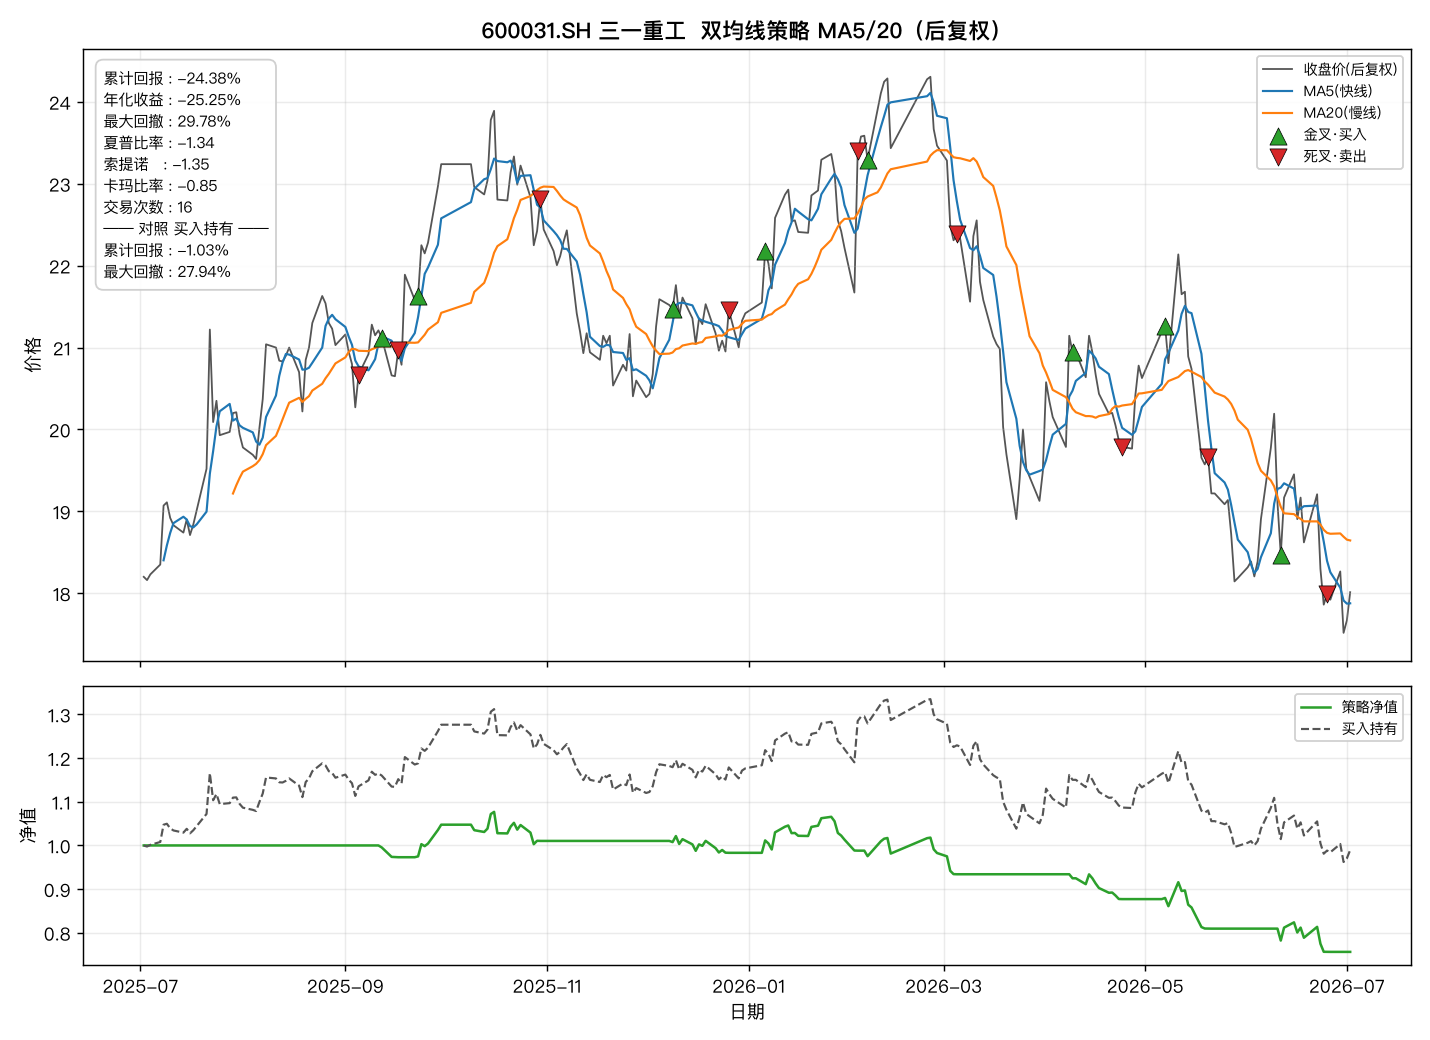

In [5]:
# 绘制该示范股的双图（价格+均线+买卖信号 / 净值对比）
from dual_ma_backtest import plot_one
os.makedirs('figs', exist_ok=True)
plot_one(bt, met, demo_code, f'figs/{demo_code}_dual_ma.png')
display(Image(filename=f'figs/{demo_code}_dual_ma.png'))


## 4. 四只股票批量回测

`run_all()` 循环 4 只股票，保存 `figs/*.png` 与 `metrics_summary.csv`，并返回汇总 DataFrame。

In [6]:
# 批量回测（区间可调：START_DATE / END_DATE）
params = dict(DEFAULTS, start_date=START_DATE, end_date=END_DATE)
summary = run_all(raw_dir, params=params)
print("\n=== metrics_summary.csv ===")
summary


[OK] 002594.SZ 比亚迪    | 累计  -20.52% | MDD  24.54% | 夏普 -1.37 | 交易  18 | 图 → /Users/xuyajing/Desktop/AI/Quant/Task 3/figs/002594.SZ_dual_ma.png
[OK] 600031.SH 三一重工   | 累计  -24.38% | MDD  29.78% | 夏普 -1.34 | 交易  16 | 图 → /Users/xuyajing/Desktop/AI/Quant/Task 3/figs/600031.SH_dual_ma.png
[OK] 600900.SH 长江电力   | 累计   -5.04% | MDD   6.33% | 夏普 -0.70 | 交易  12 | 图 → /Users/xuyajing/Desktop/AI/Quant/Task 3/figs/600900.SH_dual_ma.png
[OK] 688981.SH 中芯国际   | 累计   38.37% | MDD  24.73% | 夏普  0.94 | 交易  11 | 图 → /Users/xuyajing/Desktop/AI/Quant/Task 3/figs/688981.SH_dual_ma.png

[汇总] 已写出 → /Users/xuyajing/Desktop/AI/Quant/Task 3/metrics_summary.csv

=== metrics_summary.csv ===


,code,name,start,end,N_short,N_long,commission,cumulative_return,annualized_return,mdd,sharpe,sortino,calmar,num_trades,bh_cumulative_return,bh_mdd
0,002594.SZ,比亚迪,2025-07-03,2026-07-03,5,20,0.0003,-0.205171,-0.212677,0.245428,-1.374612,-1.442223,-0.866553,18,-0.197231,0.314394
1,600031.SH,三一重工,2025-07-02,2026-07-02,5,20,0.0003,-0.243807,-0.252489,0.297817,-1.338953,-1.349541,-0.847800,16,-0.010302,0.279399
2,600900.SH,长江电力,2025-07-03,2026-07-03,5,20,0.0003,-0.050368,-0.052394,0.063333,-0.703961,-0.676622,-0.827277,12,-0.071356,0.141248
3,688981.SH,中芯国际,2025-07-03,2026-07-03,5,20,0.0003,0.383678,0.414480,0.247263,0.939408,1.254144,1.676271,11,0.626962,0.345038



--- 002594.SZ 比亚迪 ---


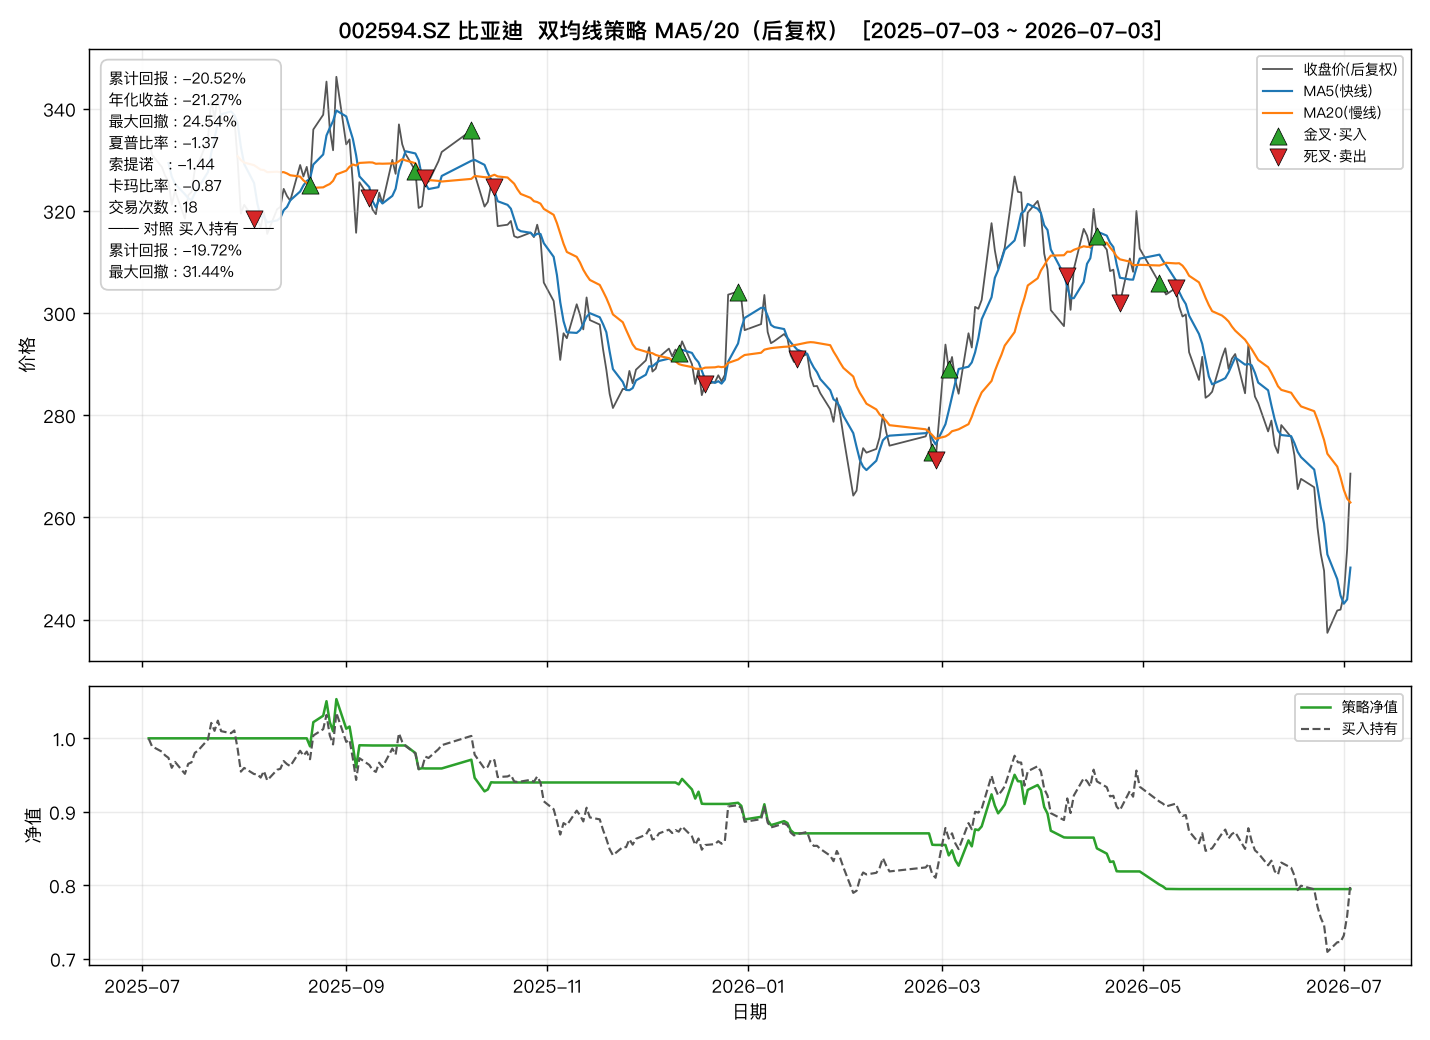


--- 600031.SH 三一重工 ---


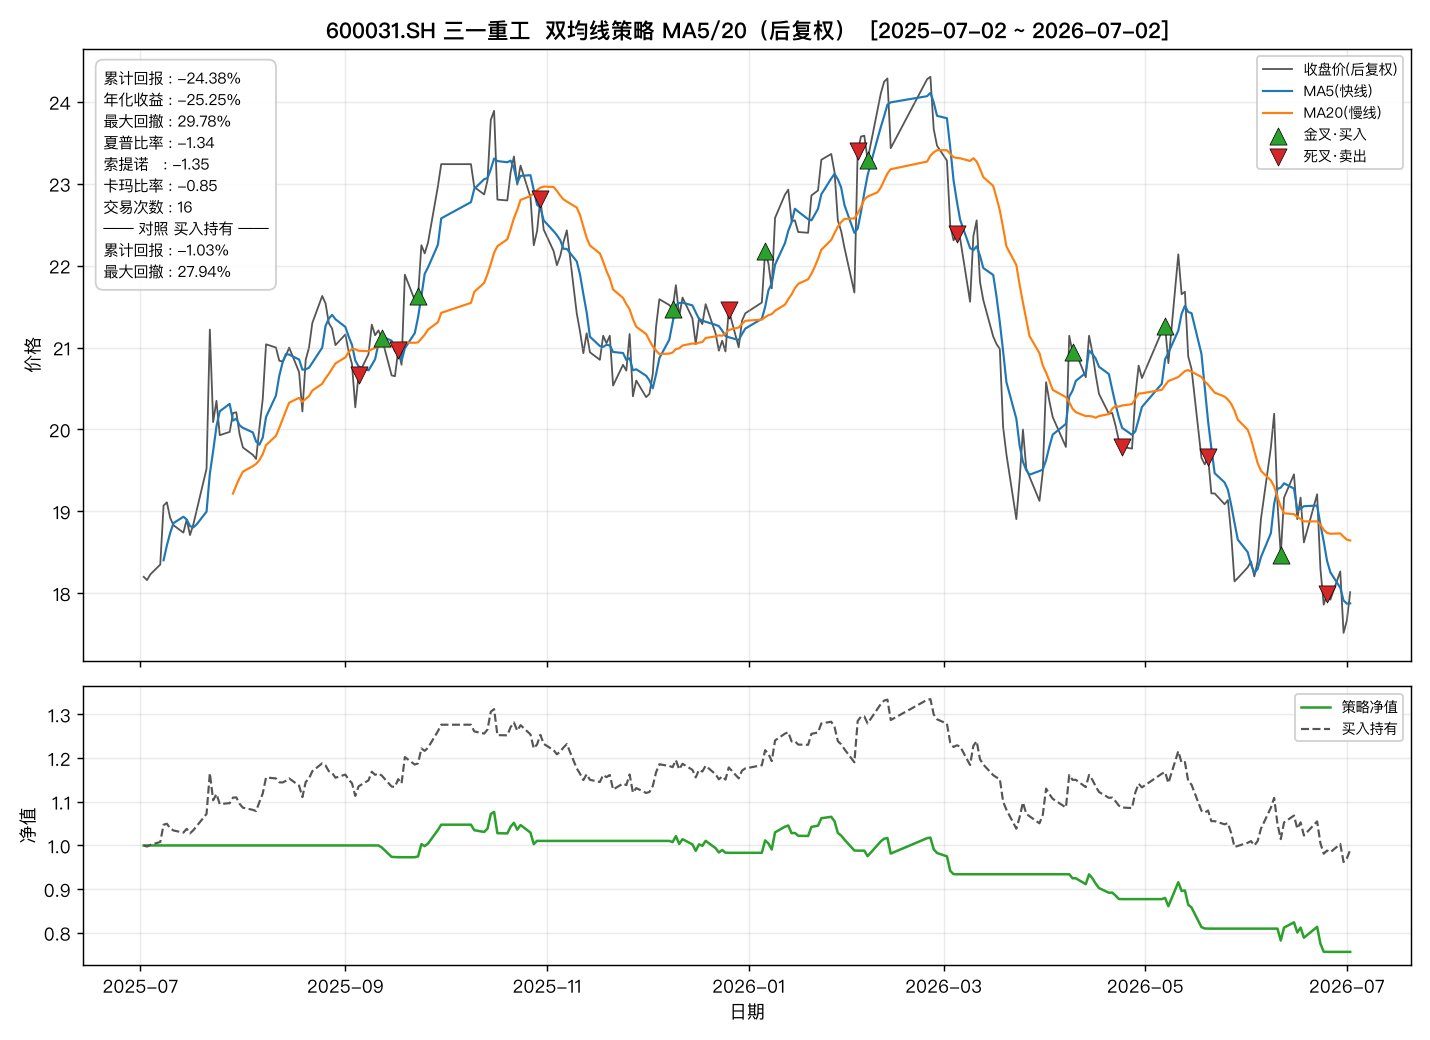


--- 600900.SH 长江电力 ---


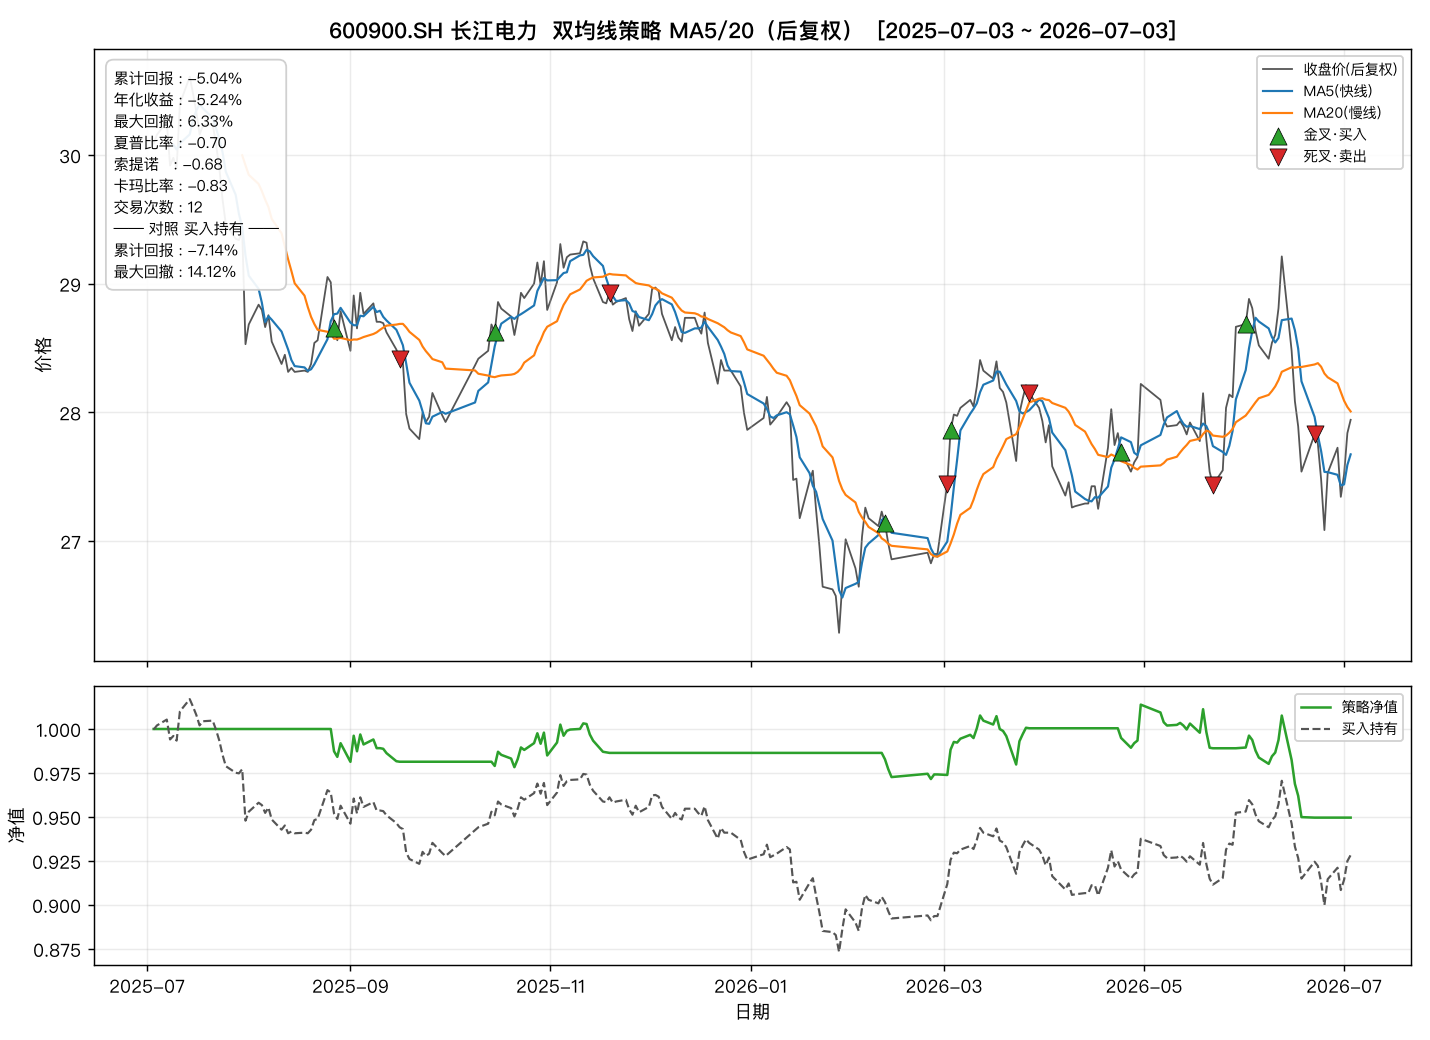


--- 688981.SH 中芯国际 ---


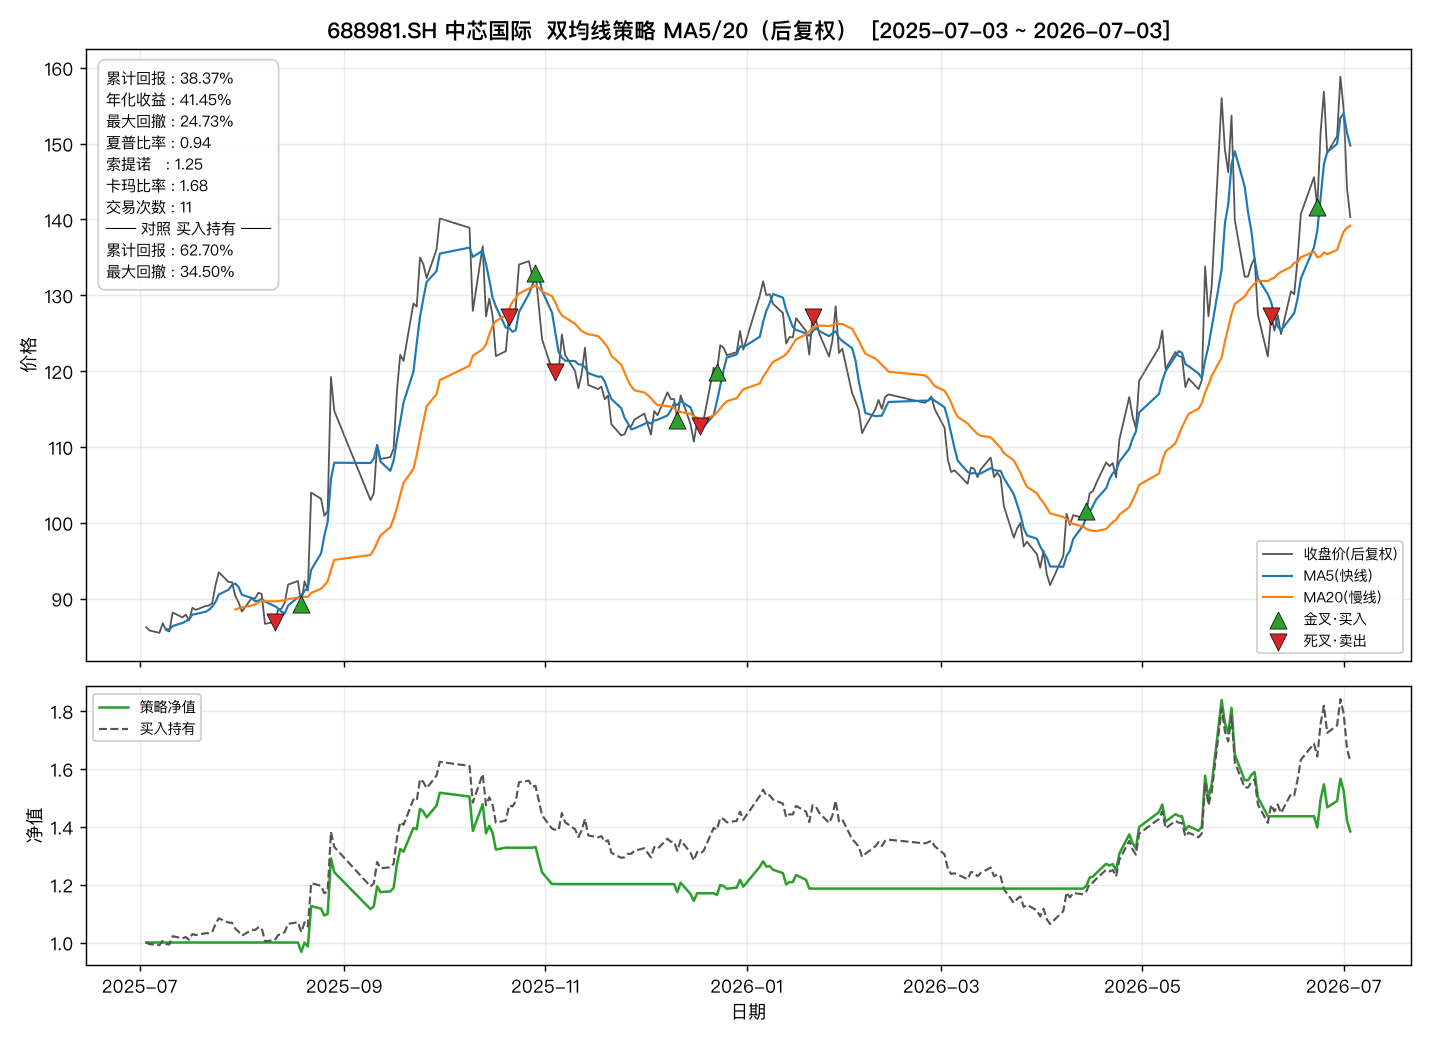

In [7]:
# 展示四只股票的结果图
for code in summary['code'].tolist():
    name = summary.loc[summary['code']==code, 'name'].iloc[0]
    print(f"\n--- {code} {name} ---")
    display(Image(filename=f'figs/{code}_dual_ma.png'))


## 5. 指标解读与参数敏感性

- **累计回报**：策略从开仓到结束资金净增长；须配合年化与回撤一起看。
- **最大回撤 MDD**：净值从峰值到谷值的最大跌幅，决定"能否拿得住"。
- **夏普比率**：每单位总风险的超额回报（年化）；>1 良好、>2 优秀。注意它惩罚上涨波动。
- **索提诺 / 卡玛**：只用下行波动 / 单位回撤换来的收益，对"怕跌不怕涨"更合理。

**调参建议**
- 缩短 `MA_short`/`MA_long` 间距 → 信号增多但假信号（震荡市反复打脸）也增多；
- 拉大间距 → 更平滑、更少交易、成本更低，但更滞后；
- 提高 `commission` 可观察高频策略在真实成本下的衰减。

在 `dual_ma_dashboard.html` 中可实时拖动参数查看图形与指标变化。
